In [1]:
#C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit

In [1]:
import chipwhisperer as cw
import chipwhisperer.common.results.glitch as glitch
import numpy as np
import time

# --- USER CONFIGURATION ---
# *** IMPORTANT: REPLACE WITH YOUR ACTUAL BITSTREAM PATH ***
BITSTREAM_FILEPATH = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit' 

# Set a fixed key and plaintext for consistent testing
KEY = bytearray([0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6, 0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C])
PLAINTEXT = bytearray([0x5C, 0x69, 0x2F, 0x91, 0x03, 0xB2, 0x30, 0x29, 0x14, 0xD7, 0xE5, 0x55, 0xE4, 0xDC, 0xEE, 0x49])
# Expected ciphertext for the fixed KEY/PLAINTEXT
EXPECTED_CIPHERTEXT = bytearray([0x06, 0xF3, 0x6A, 0x65, 0xE8, 0xA9, 0x9F, 0xF8, 0x90, 0x7B, 0x2E, 0x5E, 0x5D, 0xD7, 0x7D, 0xDE])

# Attack Parameters

VCC_INT_TARGET = 1.0 # Lower VCC-INT (e.g., 0.75V) makes the FPGA more susceptible to glitches
NUM_GLITCH_ATTEMPTS = 500 # Number of times to try glitching
NUM_NORMAL_TRACES = 10 # Number of traces without glitch for comparison

# Glitch Parameters (You will need to tune these for your setup)
GLITCH_WIDTH = 25.0 # Percentage of clock cycle
GLITCH_OFFSET = 0.0 # Percentage of clock cycle
GLITCH_REPEAT = 1 # Number of times the glitch pulse is repeated
EXT_OFFSET_SWEEP = np.arange(0, 10, 1) # Sweep through clock cycles 0 to 9 (Round 1 to Round 10)

# --- CONNECTION ---
scope = cw.scope()
target = cw.target(scope, cw.targets.CW305, bsfile=BITSTREAM_FILEPATH, force=True)

# --- CONFIGURE CW305 TARGET ---
# Set the core voltage (VCC-INT) to a lower, vulnerable level
target.vccint_set(VCC_INT_TARGET)
print(f"Target VCC-INT set to: {target.vccint_get()}V")

# Setup PLL1 on CW305 (assuming 10MHz external clock is provided by CW-Lite)
#target.pll.pll_outenable_set(True, 1) # Enable PLL1 output
#target.pll.pll_outfreq_set(50E6, 1) # Set PLL1 to 50 MHz (common FPGA clock)

# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

    # run at 10 MHz: 10E6
target.pll.pll_outfreq_set(10E6, 1)

# --- CONFIGURE CW-LITE SCOPE FOR POWER TRACING ---
# Use the clock generated by the CW305 (EXTCLK) as the ADC clock source
scope.default_setup()
scope.clock.adc_src = "extclk_x4" # Use 4x the target clock for sampling
scope.adc.samples = 3000 # Number of samples to capture per trace
scope.adc.offset = 0
scope.gain.gain = 40
scope.adc.presamples = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = 'tio4' # FPGA trigger pin TIO4 is used to arm the scope/glitch
scope.io.tio1 = "serial_tx"
scope.io.tio2 = "serial_rx"
scope.io.tio3 = "high_z" # Not used
scope.io.tio4 = "high_z" # Used for trigger, set by FPGA

# --- CONFIGURE CW-LITE GLITCH MODULE ---
scope.glitch.clk_src = "target" # Clock source for the glitch is the Target's EXTCLK
scope.glitch.trigger_src = "ext_single" # Wait for an external trigger (FPGA TIO4)
scope.glitch.output = "glitch_only" # Glitch pin pulls VCC-INT to ground (Crowbar)
scope.io.glitch_lp = True # Enable the low-power crowbar MOSFET
scope.io.glitch_hp = False
scope.glitch.width = GLITCH_WIDTH # Set glitch pulse width
scope.glitch.offset = GLITCH_OFFSET # Set glitch pulse timing offset
scope.glitch.repeat = GLITCH_REPEAT # Set number of pulses
# scope.glitch.ext_offset remains 0 by default, but we will set it in the loop

# Reset the glitch mechanism
scope.io.vglitch_reset()

OSError: Unable to communicate with found ChipWhisperer. Check that 
another process isn't connected to it and that you have permission to communicate with it.

In [2]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [3]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

# Function to run the AES encryption on the target
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

for i in range(NUM_NORMAL_TRACES):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    # The requested single-line comparison using slicing [0:6]
    if EXPECTED_CIPHERTEXT[0:6] == output[0:6]: print("hi")
    else: print("hello")
    #later---------------added for check
    # Check for communication failure
    if not success:
        print(f"Trace {i}: COMMUNICATION FAIL (Skipping)")
        continue

    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    if success:
        print(f"Trace {i}: Success, Output: {output.hex()}")
    else:
        # This should never be reached if success is true
        print(f"Trace {i}: FAIL, Output: {output.hex()}")

        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")


--- Collecting Normal Traces ---
hi
Trace 0: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 1: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 2: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 3: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 4: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 5: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 6: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 7: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 8: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
hi
Trace 9: Success, Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Baseline trace collection complete. Collected 10 good traces.


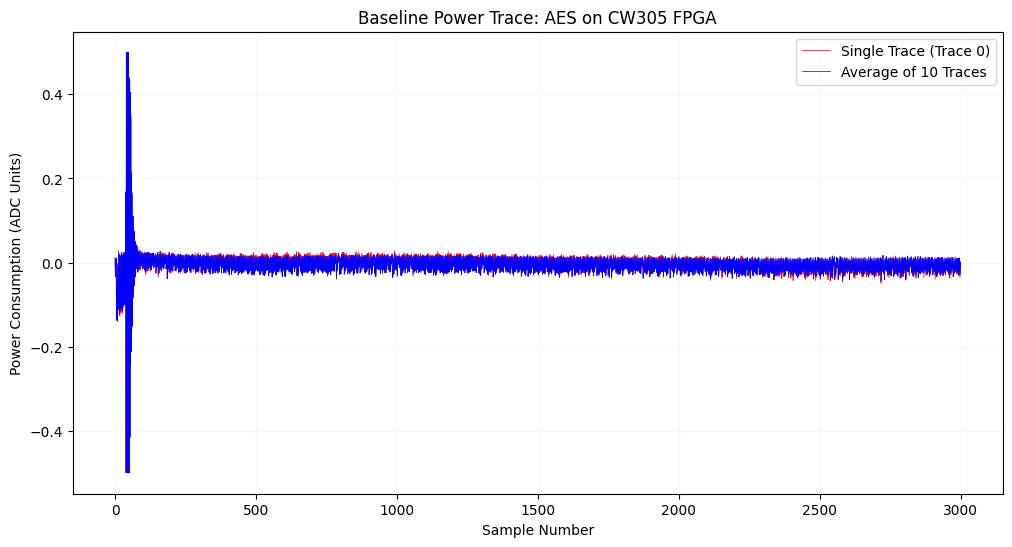

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', linewidth=0.5)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=0.5)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.1)
    plt.show()

In [6]:
# --- GLITCH ATTACK LOOP WITH SWEEP ---

# Define the sweep space
WIDTHS = np.linspace(2.0, 8.0, 4)
# 4 widths from 2.0% to 8.0%
OFFSETS = np.linspace(-30.0, 30.0, 60) 
# 60 offsets across +/- 30% of clock cycle
NUM_ATTEMPTS_PER_POINT = 3
print("\n--- Starting Glitch Sweep ---")
glitched_results = []
successful_faults = 0

for ext_offset in EXT_OFFSET_SWEEP: # NEW OUTER LOOP
    scope.glitch.ext_offset = ext_offset # Set the target AES round (clock cycle)
    print(f"\nTargeting AES Round (Ext Offset) {ext_offset}...")
    
    for width in WIDTHS:
        scope.glitch.width = width
        
        for offset in OFFSETS:
            scope.glitch.offset = offset
            
            # Run 3 attempts at this specific (width, offset) pair
            for attempt in range(NUM_ATTEMPTS_PER_POINT):
                #target.vccint_set(0.75)
                #time.sleep(0.05)
                #target.vccint_set(VCC_INT_TARGET)
                #time.sleep(0.05)
                
                i = len(glitched_results) # Track total attempts
                
                # 1. ARM Scope
                scope.arm()
                
                # 2. Glitch Operation
                output, success = run_aes(target, PLAINTEXT, KEY)

                # 3. Crash/Fault Detection
                if scope.capture():
                    glitched_results.append({'trace': None, 'output': 'TIMEOUT', 'attempt': i, 'width': width, 'offset': offset})
                    log_result = 'TIMEOUT'
                    
                    # REPROGRAM FPGA AFTER CRASH
                    try:
                        target.fpga_write(BITSTREAM_FILEPATH)
                    except:
                        pass
                    print(f"Attempt {i}: TIMEOUT (w={width:.1f}, o={offset:.1f}, ext={ext_offset}). Reprogrammed.")
                    
                    # Log the timeout result (Ensure the correct data keys are present)
                    glitched_results.append({'trace': None, 'output': log_result, 'attempt': i, 'result': log_result, 'width': width, 'offset': offset, 'ext_offset': ext_offset})
                    continue
                    
                # --- FAULT DETECTION AND LOGGING (CLEANED) ---
                
                # Check if communication failed or output is not expected
                if EXPECTED_CIPHERTEXT[0:6] != output[0:6]:
                    # A true functional fault detected!
                    print(output)
                    log_result = 'FAULT'
                    successful_faults += 1
                    print(f"Attempt {i}: **FAULT** (w={width:.1f}, o={offset:.1f}, ext={ext_offset}) Output: {output.hex()}")
                else:
                    log_result = 'NORMAL'
                    print(f"Attempt {i}: **FAULT** (w={width:.1f}, o={offset:.1f}, ext={ext_offset}) Output: {output.hex()}")    
    
                


--- Starting Glitch Sweep ---

Targeting AES Round (Ext Offset) 0...
Attempt 0: **FAULT** (w=2.0, o=-30.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-30.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-30.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-29.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-29.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-29.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-28.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-28.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-28.0, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-26.9, ext=0) Output: 06f36a65e8a99ff8907b2e5e5ddd77de
Attempt 0: **FAULT** (w=2.0, o=-26.9, ext=0) Output: 06f36a65e8a99ff89

In [ ]:
# 3. Crash/Fault Detection
                if scope.capture():
                    glitched_results.append({'trace': None, 'output': 'TIMEOUT', 'attempt': i, 'width': width, 'offset': offset})
                    
                    # REPROGRAM FPGA AFTER CRASH
                    try:
                        target.fpga_write(BITSTREAM_FILEPATH)
                    except:
                        pass
                    print(f"Attempt {i}: TIMEOUT (w={width:.1f}, o={offset:.1f}). Reprogrammed.")
                    continue
                
                # --- FAULT DETECTION ---
                if output != EXPECTED_CIPHERTEXT:
                    glitched_results.append({'trace': trace, 'output': output.hex() if output else result, 'attempt': i, 'result': glitched_results, 'width': width, 'offset': offset, 'ext_offset': ext_offset})
                # ... (rest of fault handling)
                    result = 'FAULT'
                    successful_faults += 1
                else:
                    result = 'NORMAL'
    
                    glitched_results.append({'trace': trace, 'output': output.hex() if output else result, 'attempt': i, 'result': result, 'width': width, 'offset': offset})
                
                if result == 'FAULT':
                    print(f"Attempt {i}: **FAULT** (w={width:.1f}, o={offset:.1f}) Output: {output.hex()}")
                else:
                    # Only print normal output sparingly to focus on faults/crashes
                    pass

In [ ]:
# --- GLITCH ATTACK LOOP WITH SWEEP ---

# Define the sweep space
WIDTHS = np.linspace(2.0, 8.0, 4)
# 4 widths from 2.0% to 8.0%
OFFSETS = np.linspace(-30.0, 30.0, 60) 
# 60 offsets across +/- 30% of clock cycle
NUM_ATTEMPTS_PER_POINT = 3
print("\n--- Starting Glitch Sweep ---")
glitched_results = []
successful_faults = 0
print("\n--- Starting Glitch Sweep ---")

for ext_offset in EXT_OFFSET_SWEEP: # NEW OUTER LOOP
    scope.glitch.ext_offset = ext_offset # Set the target AES round (clock cycle)
    print(f"\nTargeting AES Round (Ext Offset) {ext_offset}...")
    
    for width in WIDTHS:
        scope.glitch.width = width
        
        for offset in OFFSETS:
            scope.glitch.offset = offset
            
            # Run 3 attempts at this specific (width, offset) pair
            for attempt in range(NUM_ATTEMPTS_PER_POINT):
                #target.vccint_set(0.75)
                #time.sleep(0.05)
                #target.vccint_set(VCC_INT_TARGET)
                #time.sleep(0.05)
                
                i = len(glitched_results) # Track total attempts
                
                # 1. ARM Scope
                scope.arm()
                
                # 2. Glitch Operation
                output, success = run_aes(target, PLAINTEXT, KEY)

                # 3. Crash/Fault Detection
                if scope.capture():
                    log_result = 'TIMEOUT'    
                # --- FAULT DETECTION AND LOGGING (CLEANED) ---
                
                    # Check if communication failed or output is not expected
                    if EXPECTED_CIPHERTEXT[0:6] != output[0:6]:
                        # A true functional fault detected!
                        log_result = 'FAULT'
                        successful_faults += 1
                        # Print the faulty output (which will differ from EXPECTED_CIPHERTEXT)
                        print(f"Attempt {i}: **FAULT** (w={width:.1f}, o={offset:.1f}, ext={ext_offset}) Output: {output.hex()}")
                    else:
                        log_result = 'NORMAL'
                        print(f"Attempt {i}: **Normal** (w={width:.1f}, o={offset:.1f}, ext={ext_offset}) Output: {output.hex()}")
                    
                # Log the result for this attempt
                    glitched_results.append({
                        'trace': scope.get_last_trace(), 
                        'output': output.hex() if output else 'COMM_FAIL', 
                        'attempt': i, 
                        'result': log_result, 
                        'width': width, 
                        'offset': offset,
                        'ext_offset': ext_offset
                    })             
        
                    

In [5]:
## --- 3. GLITCH ATTACK LOOP ---
print("\n--- Starting Glitch Attack Loop ---")
glitched_results = []
successful_faults = 0
# Adjust glitch parameters if you are sweeping a range
# E.g., for sweeping:
#scope.glitch.width = np.random.uniform(5.0, 30.0) 
#scope.glitch.offset = np.random.uniform(-40.0, 40.0)

for i in range(NUM_GLITCH_ATTEMPTS):
    
    # Reset target power briefly before each glitch attempt to clear potential config corruption
    target.vccint_set(0.65)
    time.sleep(0.05)
    target.vccint_set(VCC_INT_TARGET)
    time.sleep(0.05)
    
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        # A timeout usually means the FPGA configuration was corrupted and reset
        glitched_results.append({'trace': None, 'output': 'TIMEOUT', 'attempt': i})
        print(f"Attempt {i}: TIMEOUT (Probable FPGA corruption)")
        
        # You may need to reprogram the FPGA here if the timeout persists
        try:
        # BITSTREAM_FILEPATH needs to be defined at the top of your script
            target.fpga_write(BITSTREAM_FILEPATH) 
            print(f"Attempt {i}: TIMEOUT. FPGA Reprogrammed.")
        except Exception as e:
            print(f"Attempt {i}: ERROR reprogramming FPGA ({e}).")
            time.sleep(1)
        continue
    
    trace = scope.get_last_trace()
    
    # NEW: Convert bytearray outputs to hex strings for reliable comparison
    output_hex = output.hex() if output else "N/A"
    expected_hex = EXPECTED_CIPHERTEXT.hex() 
    
    if not success or output is None:
        result = 'COMM_FAIL'
    elif output_hex != expected_hex: # <--- CRITICAL CHANGE: Comparing strings
        result = 'FAULT'
        successful_faults += 1
    else:
        result = 'NORMAL' # <--- This will now correctly show 'NORMAL'
        
    glitched_results.append({'trace': trace, 'output': output_hex, 'attempt': i, 'result': result})
    
    # Print the result using the already converted hex string
    print(f"Attempt {i}: Result: {result}, Output: {output_hex if output_hex != expected_hex else 'Correct'}")
    
    if not success or output is None:
        result = 'COMM_FAIL'
    elif output != EXPECTED_CIPHERTEXT:
        result = 'FAULT'
        successful_faults += 1
    else:
        result = 'NORMAL'
        
    glitched_results.append({'trace': trace, 'output': output.hex() if output else result, 'attempt': i, 'result': result})
    
    print(f"Attempt {i}: Result: {result}, Output: {output.hex() if output and result != 'NORMAL' else 'Correct'}")

print(f"\n--- ATTACK SUMMARY ---")
print(f"Total Attempts: {NUM_GLITCH_ATTEMPTS}")
print(f"Successful Faults Found: {successful_faults}")


--- Starting Glitch Attack Loop ---
Attempt 0: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 0: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 1: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 1: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 2: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 2: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 3: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 3: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 4: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 4: Result: FAULT, Output: ffffffffffffffffffffffffffffffff


(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 2183 vs 3000


Attempt 5: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 5: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 6: TIMEOUT (Probable FPGA corruption)
Attempt 6: ERROR reprogramming FPGA (CW305.fpga_write() missing 1 required positional argument: 'data').


(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 2999 vs 3000


Attempt 7: TIMEOUT (Probable FPGA corruption)
Attempt 7: ERROR reprogramming FPGA (CW305.fpga_write() missing 1 required positional argument: 'data').
Attempt 8: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 8: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 9: Result: FAULT, Output: ffffffffffffffffffffffffffffffff
Attempt 9: Result: FAULT, Output: ffffffffffffffffffffffffffffffff


...

Attempt 497: TIMEOUT (Probable FPGA corruption)
Attempt 497: ERROR reprogramming FPGA (CW305.fpga_write() missing 1 required positional argument: 'data').


(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 2999 vs 3000


Attempt 498: TIMEOUT (Probable FPGA corruption)
Attempt 498: ERROR reprogramming FPGA (CW305.fpga_write() missing 1 required positional argument: 'data').


(ChipWhisperer Scope ERROR|File OpenADC.py:824) Received fewer points than expected: 2999 vs 3000


Attempt 499: TIMEOUT (Probable FPGA corruption)
Attempt 499: ERROR reprogramming FPGA (CW305.fpga_write() missing 1 required positional argument: 'data').

--- ATTACK SUMMARY ---
Total Attempts: 500
Successful Faults Found: 318


In [ ]:
glitched_results.append({'trace': None, 'output': 'TIMEOUT', 'attempt': i, 'width': width, 'offset': offset})
                    log_result = 'TIMEOUT'
                    
                    # REPROGRAM FPGA AFTER CRASH
                    try:
                        target.fpga_write(BITSTREAM_FILEPATH)
                    except:
                        pass
                    print(f"Attempt {i}: TIMEOUT (w={width:.1f}, o={offset:.1f}, ext={ext_offset}). Reprogrammed.")
                    
                    # Log the timeout result (Ensure the correct data keys are present)
                    glitched_results.append({'trace': None, 'output': log_result, 'attempt': i, 'result': log_result, 'width': width, 'offset': offset, 'ext_offset': ext_offset})
                    continue